🔥 Forest Fire Prediction System
Complete Pipeline — Cleaned, Fixed & Production-Ready

1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import glob
import joblib
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (mean_absolute_error, mean_squared_error,
                             r2_score, accuracy_score, confusion_matrix)
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import TimeSeriesSplit

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

 2. Load Dataset

In [2]:
path  = "../MP_fire_dataset/*.csv"
files = glob.glob(path)

df_list = []
for f in files:
    temp = pd.read_csv(f, encoding='latin1')
    df_list.append(temp)

df = pd.concat(df_list, ignore_index=True)

print("Data loaded:", df.shape)
print("Columns BEFORE cleaning:", df.columns.tolist())

Data loaded: (104641, 15)
Columns BEFORE cleaning: ['latitude', 'longitude', 'brightness', 'scan', 'track', 'acq_date', 'acq_time', 'satellite', 'instrument', 'confidence', 'version', 'bright_t31', 'frp', 'daynight', 'type']


 3. Data Cleaning

In [3]:
# Parse date
df['acq_date'] = pd.to_datetime(df['acq_date'], errors='coerce')
df = df.dropna(subset=['acq_date', 'frp'])

# FRP must be positive
df = df[df['frp'] > 0].reset_index(drop=True)

# Sort by location + date — CRITICAL for correct lag features
df = df.sort_values(['latitude', 'longitude', 'acq_date']).reset_index(drop=True)

# Day/Night encoding
df['daynight'] = df['daynight'].map({'D': 1, 'N': 0}).fillna(1).astype(int)

# Extract hour from acq_time
df['acq_time'] = df['acq_time'].astype(str).str.zfill(4)
df['hour']     = pd.to_numeric(df['acq_time'].str[:2], errors='coerce').fillna(12).astype(int)

# Drop columns not available at inference time
df.drop(columns=['acq_time', 'satellite', 'instrument', 'version', 'type'],
        errors='ignore', inplace=True)

# Remove unnamed index columns
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

print("After cleaning:", df.shape)
print(df.isnull().sum())

After cleaning: (38226, 11)
latitude      0
longitude     0
brightness    0
scan          0
track         0
acq_date      0
confidence    0
bright_t31    0
frp           0
daynight      0
hour          0
dtype: int64


## 4. FRP Distribution

In [4]:
frp = df['frp']

ranges = {
    "0-10":    ((frp >= 0)   & (frp < 10)).sum(),
    "10-20":   ((frp >= 10)  & (frp < 20)).sum(),
    "20-50":   ((frp >= 20)  & (frp < 50)).sum(),
    "50-100":  ((frp >= 50)  & (frp < 100)).sum(),
    "100-200": ((frp >= 100) & (frp < 200)).sum(),
    "200-500": ((frp >= 200) & (frp < 500)).sum(),
    "500+":    (frp >= 500).sum()
}

print("FRP Distribution:")
for k, v in ranges.items():
    print(f"  {k:>10}: {v}")

FRP Distribution:
        0-10: 13085
       10-20: 13699
       20-50: 8835
      50-100: 2017
     100-200: 481
     200-500: 102
        500+: 7


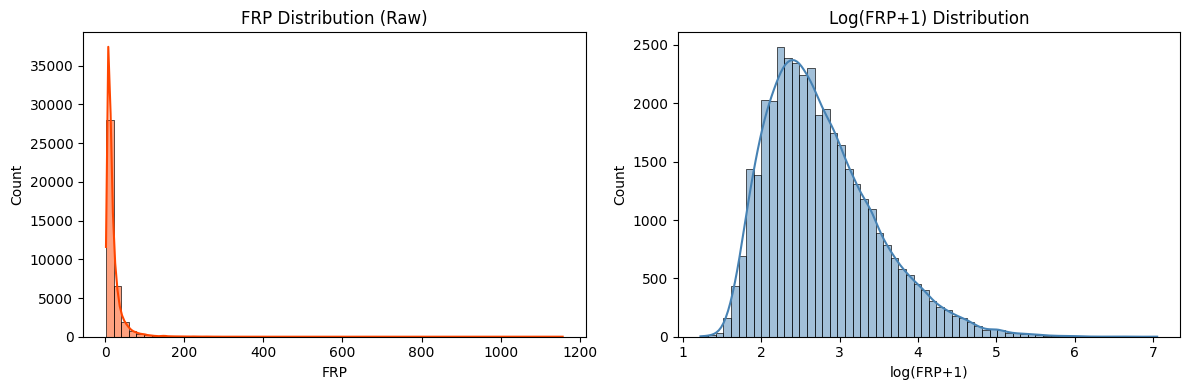

In [5]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
sns.histplot(df['frp'], bins=60, kde=True, color='orangered')
plt.title("FRP Distribution (Raw)")
plt.xlabel("FRP")

plt.subplot(1, 2, 2)
sns.histplot(np.log1p(df['frp']), bins=60, kde=True, color='steelblue')
plt.title("Log(FRP+1) Distribution")
plt.xlabel("log(FRP+1)")

plt.tight_layout()
plt.show()

## 5. Feature Engineering
> `prev_frp` and rolling features use `.shift(1)` — they only look at the **past**, so there is no data leakage. The train/test split is time-based, so test rows never influence training lag values.

In [6]:
# --- Time Features ---
df['month']     = df['acq_date'].dt.month
df['dayofyear'] = df['acq_date'].dt.dayofyear

# --- Cyclical Encoding (sin + cos needed for full angle) ---
df['hour_sin']  = np.sin(2 * np.pi * df['hour']  / 24)
df['hour_cos']  = np.cos(2 * np.pi * df['hour']  / 24)
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

# --- Lag Feature: Previous FRP at same location ---
df['prev_frp'] = (
    df.groupby(['latitude', 'longitude'])['frp']
    .shift(1)
)

# --- Rolling Features: 3-obs mean and 7-obs max ---
df['frp_rolling_mean_3'] = (
    df.groupby(['latitude', 'longitude'])['frp']
    .transform(lambda x: x.shift(1).rolling(3, min_periods=1).mean())
)

df['frp_rolling_max_7'] = (
    df.groupby(['latitude', 'longitude'])['frp']
    .transform(lambda x: x.shift(1).rolling(7, min_periods=1).max())
)

# --- Interaction Feature ---
df['brightness_confidence'] = df['brightness'] * df['confidence']

# --- Season Feature ---
season_map = {
    12:'winter', 1:'winter',  2:'winter',
     3:'spring', 4:'spring',  5:'spring',
     6:'summer', 7:'summer',  8:'summer',
     9:'autumn', 10:'autumn', 11:'autumn'
}
df['season'] = df['month'].map(season_map)
df = pd.get_dummies(df, columns=['season'], drop_first=True)

# --- Fill NaN from lag/rolling ---
num_cols = df.select_dtypes(include=[np.number]).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())
df = df.dropna().reset_index(drop=True)

print("After feature engineering:", df.shape)

After feature engineering: (38226, 24)


## 6. Define Features & Target

In [7]:
base_features = [
    'latitude', 'longitude', 'daynight',
    'brightness', 'confidence', 'scan', 'track', 'bright_t31',
    'hour', 'month', 'dayofyear',
    'hour_sin', 'hour_cos', 'month_sin', 'month_cos',
    'brightness_confidence',
    'prev_frp',
    'frp_rolling_mean_3',
    'frp_rolling_max_7'
]

# Add season dummies that were created
season_cols  = [c for c in df.columns if c.startswith('season_')]
feature_cols = base_features + season_cols
feature_cols = [c for c in feature_cols if c in df.columns]

X = df[feature_cols]
y = df['frp']

print("Features:", feature_cols)
print("X shape:",  X.shape)

Features: ['latitude', 'longitude', 'daynight', 'brightness', 'confidence', 'scan', 'track', 'bright_t31', 'hour', 'month', 'dayofyear', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'brightness_confidence', 'prev_frp', 'frp_rolling_mean_3', 'frp_rolling_max_7', 'season_spring', 'season_summer', 'season_winter']
X shape: (38226, 22)


## 7. Train-Test Split (Time-Based — 80/20)

In [8]:
split_idx = int(len(X) * 0.8)

X_train = X.iloc[:split_idx].copy()
X_test  = X.iloc[split_idx:].copy()
y_train = y.iloc[:split_idx].copy()
y_test  = y.iloc[split_idx:].copy()

print("Train:", X_train.shape, "| Test:", X_test.shape)

# Log-transformed targets
y_train_log = np.log1p(y_train)
y_test_log  = np.log1p(y_test)

Train: (30580, 22) | Test: (7646, 22)


## 8. Classification Thresholds (Train Only — No Leakage)

In [9]:
# Computed ONLY from y_train so test distribution never influences thresholds
q1 = y_train.quantile(0.33)
q2 = y_train.quantile(0.66)

print(f"Thresholds → Low < {q1:.2f}  |  Medium < {q2:.2f}  |  High >= {q2:.2f}")

def categorize(x, q1=q1, q2=q2):
    if x < q1:   return "Low"
    elif x < q2: return "Medium"
    else:        return "High"

Thresholds → Low < 9.80  |  Medium < 18.10  |  High >= 18.10


## 9. Scaling

In [10]:
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)   # fit ONLY on train
X_test_s  = scaler.transform(X_test)        # apply same scale to test

## 10. Linear Regression

In [11]:
lr = LinearRegression()
lr.fit(X_train_s, y_train_log)

lr_pred       = np.expm1(lr.predict(X_test_s))
lr_train_pred = np.expm1(lr.predict(X_train_s))

# Feature weights
weights = pd.Series(lr.coef_, index=X_train.columns).sort_values()
print("Linear Regression Weights:\n", weights)

Linear Regression Weights:
 dayofyear               -0.396412
bright_t31              -0.296152
confidence              -0.083477
daynight                -0.032596
season_winter           -0.008319
latitude                -0.003587
season_summer           -0.002691
season_spring           -0.002443
hour_cos                -0.001173
frp_rolling_max_7        0.000411
frp_rolling_mean_3       0.000411
prev_frp                 0.000411
month_cos                0.000427
longitude                0.000842
month_sin                0.004147
hour_sin                 0.045714
hour                     0.067948
scan                     0.112236
brightness_confidence    0.219139
track                    0.300382
month                    0.390002
brightness               0.665981
dtype: float64


## 11. Random Forest

In [12]:
rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=12,
    min_samples_split=10,
    min_samples_leaf=5,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)

# RF works well on original (un-logged) target
rf.fit(X_train, y_train)

rf_pred       = rf.predict(X_test)
rf_train_pred = rf.predict(X_train)

print("Random Forest training complete")

Random Forest training complete


## 12. XGBoost

In [13]:
xgb = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.03,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    gamma=0.1,
    reg_alpha=0.05,
    reg_lambda=2,
    min_child_weight=2,
    random_state=42,
    n_jobs=-1,
    verbosity=0
)

xgb.fit(
    X_train, y_train_log,
    eval_set=[(X_test, y_test_log)],
    verbose=False
)

xgb_pred       = np.expm1(xgb.predict(X_test))
xgb_train_pred = np.expm1(xgb.predict(X_train))

print("XGBoost training complete")

XGBoost training complete


## 13. Tune Ensemble Weights (Grid Search)

In [14]:
best_w, best_r2 = 0.6, -999

for w in np.arange(0.1, 1.0, 0.1):
    ep  = w * xgb_pred + (1 - w) * rf_pred
    r2  = r2_score(y_test, ep)
    if r2 > best_r2:
        best_r2 = r2
        best_w  = round(w, 1)

print(f"Best XGB weight: {best_w}  |  Best Ensemble R²: {best_r2:.4f}")

ensemble_pred       = best_w * xgb_pred       + (1 - best_w) * rf_pred
ensemble_train_pred = best_w * xgb_train_pred + (1 - best_w) * rf_train_pred

Best XGB weight: 0.5  |  Best Ensemble R²: 0.9494


## 14. SVR (10k Sample — SVR Doesn't Scale to Large Data)

In [15]:
SAMPLE = 10000

X_sample = X_train_s[:SAMPLE]
y_sample = y_train_log.iloc[:SAMPLE]

svm = SVR(kernel='rbf', C=20, epsilon=0.1)
svm.fit(X_sample, y_sample)

svm_pred       = np.expm1(svm.predict(X_test_s))
svm_train_pred = np.expm1(svm.predict(X_sample))

print("SVR training complete (on 10k sample)")

SVR training complete (on 10k sample)


## 15. LSTM — Prepare Sequences

In [16]:
y_scaler = MinMaxScaler()
y_train_scaled = y_scaler.fit_transform(y_train.values.reshape(-1, 1))
y_test_scaled  = y_scaler.transform(y_test.values.reshape(-1, 1))

TIME_STEPS = 7

def create_lstm_data(X, y, time_steps=TIME_STEPS):
    Xs, ys = [], []
    for i in range(len(X) - time_steps):
        Xs.append(X[i : i + time_steps])
        ys.append(y[i + time_steps])
    return np.array(Xs), np.array(ys)

X_lstm,      y_lstm      = create_lstm_data(X_train_s, y_train_scaled)
X_test_lstm, y_test_lstm = create_lstm_data(X_test_s,  y_test_scaled)

print("LSTM train shape:", X_lstm.shape)
print("LSTM test  shape:", X_test_lstm.shape)

LSTM train shape: (30573, 7, 22)
LSTM test  shape: (7639, 7, 22)


## 16. LSTM — Build & Train

In [17]:
lstm_model = Sequential([
    LSTM(64, return_sequences=True,
         input_shape=(X_lstm.shape[1], X_lstm.shape[2])),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(1)
])

lstm_model.compile(optimizer='adam', loss='mse')
lstm_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 7, 64)          │        22,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 7, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,721 (135.63 KB)

 Trainable params: 34,721 (135.63 KB)

 Non-trainable params: 0 (0.00 B)

In [18]:
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history = lstm_model.fit(
    X_lstm, y_lstm,
    epochs=20,
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/20
430/430 ━━━━━━━━━━━━━━━━━━━━ 17s 27ms/step - loss: 9.7833e-04 - val_loss: 9.7184e-04
Epoch 2/20
430/430 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - loss: 5.0540e-04 - val_loss: 9.5316e-04
Epoch 3/20
430/430 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - loss: 4.8376e-04 - val_loss: 9.6258e-04
Epoch 4/20
430/430 ━━━━━━━━━━━━━━━━━━━━ 11s 24ms/step - loss: 4.6282e-04 - val_loss: 9.5627e-04
Epoch 5/20
430/430 ━━━━━━━━━━━━━━━━━━━━ 11s 24ms/step - loss: 4.5805e-04 - val_loss: 9.5872e-04


## 17. LSTM — Predict & Inverse Transform
> ✅ **Fix:** Both `y_true` and `y_pred` are inverse-transformed before evaluation. Original code compared scaled (0–1) predictions against MW-scale actuals.

In [19]:
lstm_pred_scaled  = lstm_model.predict(X_test_lstm).flatten()
lstm_train_scaled = lstm_model.predict(X_lstm).flatten()

# Convert back to original FRP scale (MW)
lstm_pred_actual       = y_scaler.inverse_transform(lstm_pred_scaled.reshape(-1, 1)).flatten()
y_test_lstm_actual     = y_scaler.inverse_transform(y_test_lstm.reshape(-1, 1)).flatten()

lstm_train_pred_actual = y_scaler.inverse_transform(lstm_train_scaled.reshape(-1, 1)).flatten()
y_train_lstm_actual    = y_scaler.inverse_transform(y_lstm.reshape(-1, 1)).flatten()

239/239 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step
956/956 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step


## 18. Evaluation — Test & Train Metrics

In [20]:
def evaluate_silent(y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    return mae, rmse, r2

def evaluate(y_true, y_pred, name):
    mae, rmse, r2 = evaluate_silent(y_true, y_pred)
    print(f"{name:22s} → MAE={mae:.2f}  RMSE={rmse:.2f}  R²={r2:.4f}")
    return [name, mae, rmse, r2]

In [21]:
print("\n========== TEST METRICS ==========")
test_results = []
test_results.append(evaluate(y_test,             lr_pred,          "Linear Regression"))
test_results.append(evaluate(y_test,             rf_pred,          "Random Forest"))
test_results.append(evaluate(y_test,             xgb_pred,         "XGBoost"))
test_results.append(evaluate(y_test,             svm_pred,         "SVR"))
test_results.append(evaluate(y_test,             ensemble_pred,    "Ensemble"))
test_results.append(evaluate(y_test_lstm_actual, lstm_pred_actual, "LSTM"))

test_df = pd.DataFrame(test_results, columns=["Model", "MAE", "RMSE", "R²"])
print("\n", test_df.sort_values("R²", ascending=False).to_string(index=False))


========== TEST METRICS ==========
Linear Regression      → MAE=3.76  RMSE=22.38  R²=0.3383
Random Forest          → MAE=3.19  RMSE=6.91  R²=0.9369
XGBoost                → MAE=2.37  RMSE=6.90  R²=0.9371
SVR                    → MAE=7.28  RMSE=17.72  R²=0.5852
Ensemble               → MAE=2.59  RMSE=6.19  R²=0.9494
LSTM                   → MAE=15.51  RMSE=27.53  R²=-0.0008

             Model       MAE      RMSE        R²
         Ensemble  2.590950  6.187382  0.949410
          XGBoost  2.371204  6.900563  0.937076
    Random Forest  3.192764  6.910097  0.936902
              SVR  7.281275 17.717803  0.585172
Linear Regression  3.756667 22.378004  0.338254
             LSTM 15.513554 27.529267 -0.000756


In [22]:
print("\n========== TRAIN METRICS ==========")
train_results = []
train_results.append(evaluate(y_train,              lr_train_pred,         "Linear Regression"))
train_results.append(evaluate(y_train,              rf_train_pred,         "Random Forest"))
train_results.append(evaluate(y_train,              xgb_train_pred,        "XGBoost"))
train_results.append(evaluate(y_train.iloc[:SAMPLE], svm_train_pred,       "SVR (10k sample)"))
train_results.append(evaluate(y_train,              ensemble_train_pred,   "Ensemble"))
train_results.append(evaluate(y_train_lstm_actual,  lstm_train_pred_actual,"LSTM"))

train_df = pd.DataFrame(train_results, columns=["Model", "MAE", "RMSE", "R²"])
print("\n", train_df.sort_values("R²", ascending=False).to_string(index=False))


========== TRAIN METRICS ==========
Linear Regression      → MAE=3.99  RMSE=73.38  R²=-7.1108
Random Forest          → MAE=2.40  RMSE=7.16  R²=0.9227
XGBoost                → MAE=1.77  RMSE=6.47  R²=0.9369
SVR (10k sample)       → MAE=1.45  RMSE=2.43  R²=0.9841
Ensemble               → MAE=1.95  RMSE=6.46  R²=0.9372
LSTM                   → MAE=13.64  RMSE=25.77  R²=-0.0005

             Model       MAE      RMSE        R²
 SVR (10k sample)  1.453430  2.426404  0.984091
         Ensemble  1.953841  6.457920  0.937175
          XGBoost  1.774180  6.469515  0.936949
    Random Forest  2.396589  7.164528  0.922675
             LSTM 13.641786 25.773349 -0.000460
Linear Regression  3.991269 73.376764 -7.110806


## 19. Classification Accuracy (Low / Medium / High)

In [23]:
y_test_labels   = y_test.apply(categorize)
lr_labels       = pd.Series(lr_pred,       index=y_test.index).apply(categorize)
rf_labels       = pd.Series(rf_pred,       index=y_test.index).apply(categorize)
xgb_labels      = pd.Series(xgb_pred,      index=y_test.index).apply(categorize)
svm_labels      = pd.Series(svm_pred,      index=y_test.index).apply(categorize)
ensemble_labels = pd.Series(ensemble_pred, index=y_test.index).apply(categorize)

# LSTM: length is shorter by TIME_STEPS due to windowing
lstm_labels     = pd.Series(lstm_pred_actual).apply(categorize)
y_lstm_lbl      = pd.Series(y_test_lstm_actual).apply(categorize)
min_len         = min(len(y_lstm_lbl), len(lstm_labels))

accuracy_results = pd.DataFrame({
    "Model": ["XGBoost", "Ensemble", "Random Forest",
              "Linear Regression", "SVR", "LSTM"],
    "Accuracy (%)": [
        accuracy_score(y_test_labels, xgb_labels)      * 100,
        accuracy_score(y_test_labels, ensemble_labels)  * 100,
        accuracy_score(y_test_labels, rf_labels)        * 100,
        accuracy_score(y_test_labels, lr_labels)        * 100,
        accuracy_score(y_test_labels, svm_labels)       * 100,
        accuracy_score(y_lstm_lbl[:min_len],
                       lstm_labels[:min_len])            * 100,
    ]
})

accuracy_results["Accuracy (%)"] = accuracy_results["Accuracy (%)"].round(2)
print("\n===== CLASSIFICATION ACCURACY =====")
print(accuracy_results.sort_values("Accuracy (%)", ascending=False).to_string(index=False))

print("\n===== CLASS DISTRIBUTION =====")
print(y_test_labels.value_counts(normalize=True).round(3))


===== CLASSIFICATION ACCURACY =====
            Model  Accuracy (%)
          XGBoost         88.56
         Ensemble         87.65
Linear Regression         85.18
    Random Forest         84.38
              SVR         67.37
             LSTM         35.17

===== CLASS DISTRIBUTION =====
frp
High      0.345
Low       0.339
Medium    0.316
Name: proportion, dtype: float64


## 20. Time Series Cross-Validation

In [24]:
tscv      = TimeSeriesSplit(n_splits=5)
cv_scores = []

for fold, (train_i, test_i) in enumerate(tscv.split(X)):
    X_tr, X_te = X.iloc[train_i], X.iloc[test_i]
    y_tr, y_te = y.iloc[train_i], y.iloc[test_i]

    cv_model = XGBRegressor(
        n_estimators=300, learning_rate=0.05,
        max_depth=6, subsample=0.8,
        colsample_bytree=0.8, random_state=42, verbosity=0
    )
    cv_model.fit(X_tr, np.log1p(y_tr))
    pred  = np.expm1(cv_model.predict(X_te))
    score = r2_score(y_te, pred)
    cv_scores.append(score)
    print(f"  Fold {fold+1}: R² = {score:.4f}")

print(f"\nMean CV R²: {np.mean(cv_scores):.4f}  ±  {np.std(cv_scores):.4f}")

  Fold 1: R² = 0.5872
  Fold 2: R² = 0.9389
  Fold 3: R² = 0.9258
  Fold 4: R² = 0.8351
  Fold 5: R² = 0.9506

Mean CV R²: 0.8475  ±  0.1364


## 21. Visualisations

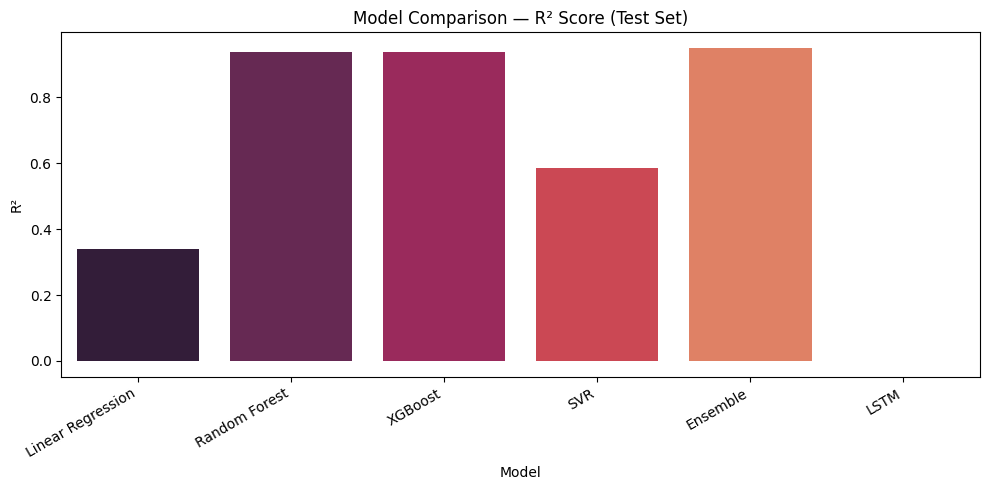

In [25]:
# --- R² Bar Chart ---
plt.figure(figsize=(10, 5))
sns.barplot(data=test_df, x="Model", y="R²", palette="rocket")
plt.title("Model Comparison — R² Score (Test Set)")
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

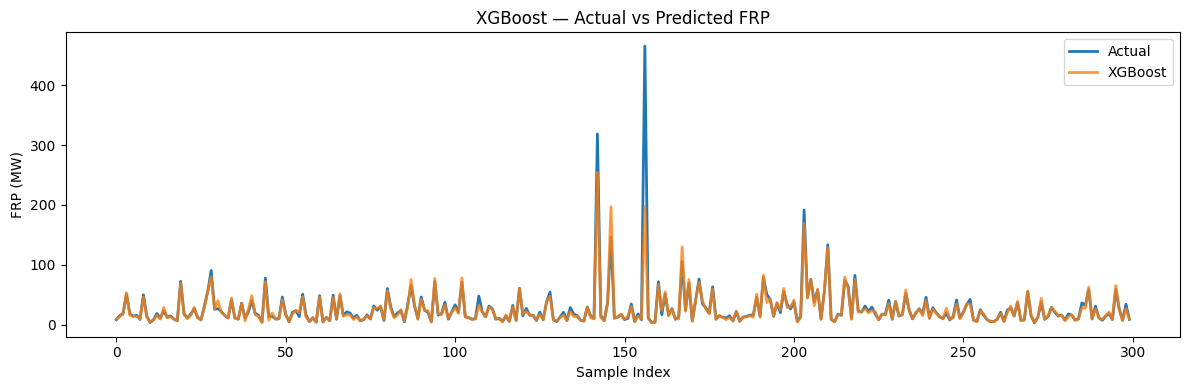

In [26]:
# --- XGBoost: Actual vs Predicted ---
N = 300
plt.figure(figsize=(12, 4))
plt.plot(y_test.values[:N], label="Actual",  linewidth=2)
plt.plot(xgb_pred[:N],      label="XGBoost", linewidth=2, alpha=0.8)
plt.title("XGBoost — Actual vs Predicted FRP")
plt.xlabel("Sample Index")
plt.ylabel("FRP (MW)")
plt.legend()
plt.tight_layout()
plt.show()

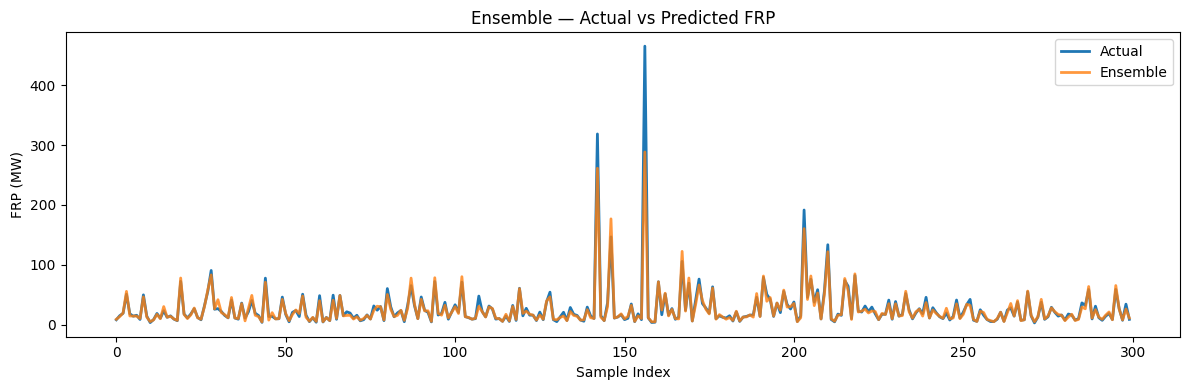

In [27]:
# --- Ensemble: Actual vs Predicted ---
plt.figure(figsize=(12, 4))
plt.plot(y_test.values[:N], label="Actual",   linewidth=2)
plt.plot(ensemble_pred[:N], label="Ensemble", linewidth=2, alpha=0.8)
plt.title("Ensemble — Actual vs Predicted FRP")
plt.xlabel("Sample Index")
plt.ylabel("FRP (MW)")
plt.legend()
plt.tight_layout()
plt.show()

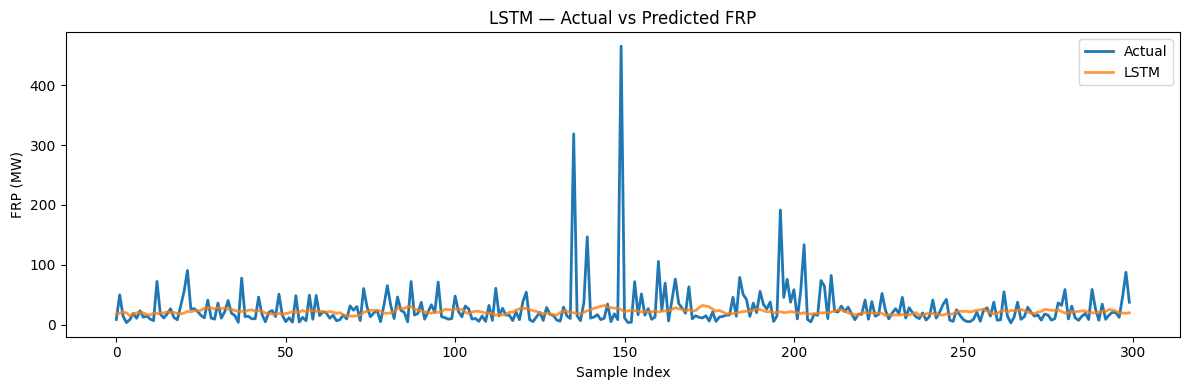

In [28]:
# --- LSTM: Actual vs Predicted ---
plt.figure(figsize=(12, 4))
plt.plot(y_test_lstm_actual[:N], label="Actual", linewidth=2)
plt.plot(lstm_pred_actual[:N],   label="LSTM",   linewidth=2, alpha=0.8)
plt.title("LSTM — Actual vs Predicted FRP")
plt.xlabel("Sample Index")
plt.ylabel("FRP (MW)")
plt.legend()
plt.tight_layout()
plt.show()

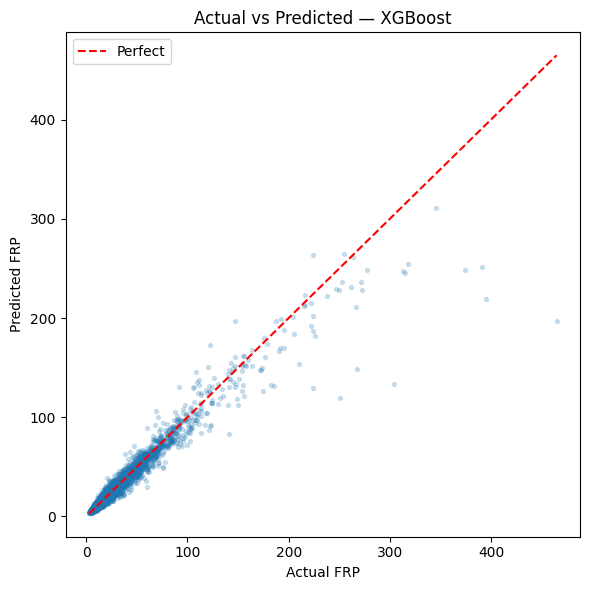

In [29]:
# --- Scatter: Actual vs Predicted (XGBoost) ---
plt.figure(figsize=(6, 6))
plt.scatter(y_test, xgb_pred, alpha=0.2, s=8)
lims = [y_test.min(), y_test.max()]
plt.plot(lims, lims, 'r--', linewidth=1.5, label="Perfect")
plt.title("Actual vs Predicted — XGBoost")
plt.xlabel("Actual FRP")
plt.ylabel("Predicted FRP")
plt.legend()
plt.tight_layout()
plt.show()

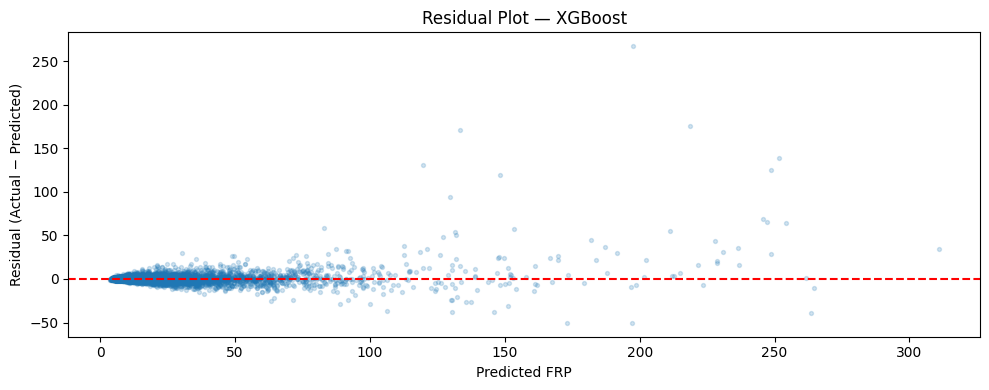

In [30]:
# --- Residual Plot ---
residuals = y_test.values - xgb_pred
plt.figure(figsize=(10, 4))
plt.scatter(xgb_pred, residuals, alpha=0.2, s=8)
plt.axhline(0, color='red', linestyle='--')
plt.title("Residual Plot — XGBoost")
plt.xlabel("Predicted FRP")
plt.ylabel("Residual (Actual − Predicted)")
plt.tight_layout()
plt.show()

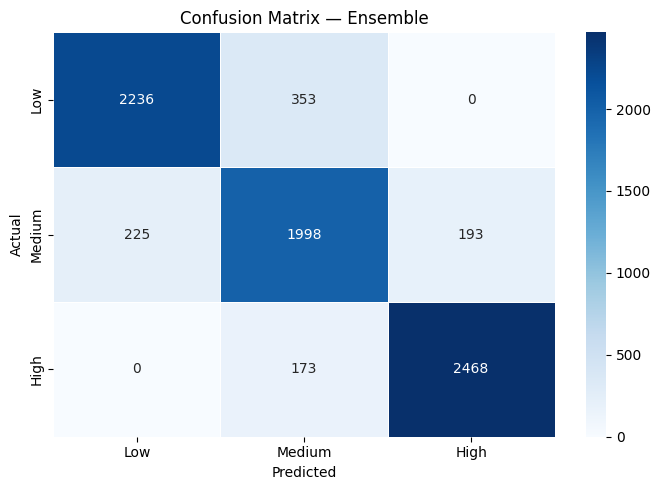

In [31]:
# --- Confusion Matrix (Ensemble) ---
ensemble_cat = pd.Series(ensemble_pred, index=y_test.index).apply(categorize)
y_test_cat   = y_test.apply(categorize)

labels = ["Low", "Medium", "High"]
cm     = confusion_matrix(y_test_cat, ensemble_cat, labels=labels)
cm_df  = pd.DataFrame(cm, index=labels, columns=labels)

plt.figure(figsize=(7, 5))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues', linewidths=0.5)
plt.title("Confusion Matrix — Ensemble")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

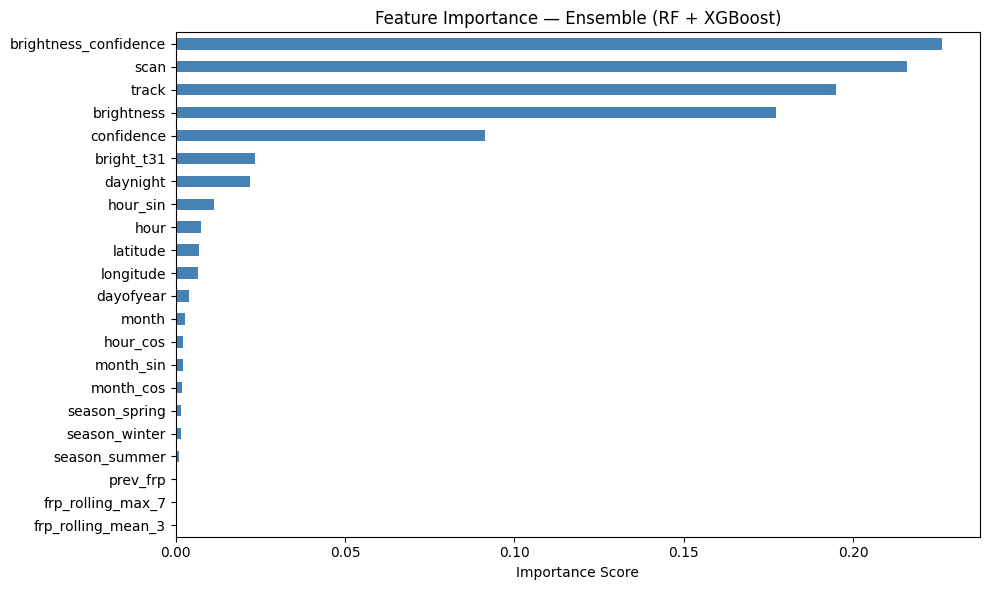

In [32]:
# --- Feature Importance (Ensemble-weighted) ---
rf_imp  = rf.feature_importances_
xgb_imp = xgb.feature_importances_
ens_imp = (1 - best_w) * rf_imp + best_w * xgb_imp

feat_imp = pd.Series(ens_imp, index=X_train.columns).sort_values(ascending=True)

plt.figure(figsize=(10, 6))
feat_imp.plot(kind='barh', color='steelblue')
plt.title("Feature Importance — Ensemble (RF + XGBoost)")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

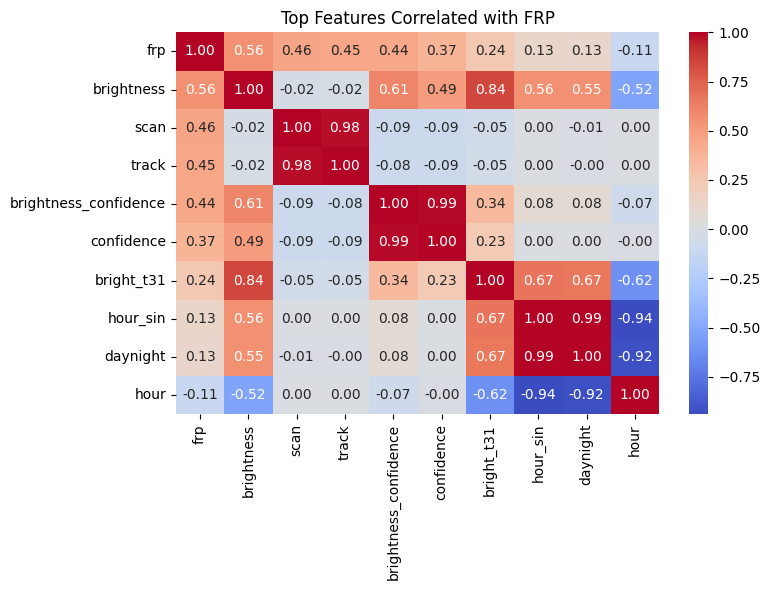

In [33]:
# --- Correlation Heatmap ---
top_cols = df.corr(numeric_only=True)['frp'].abs() \
             .sort_values(ascending=False).head(10).index

plt.figure(figsize=(8, 6))
sns.heatmap(df[top_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Top Features Correlated with FRP")
plt.tight_layout()
plt.show()

In [34]:
# --- Worst Predictions ---
errors_df = pd.DataFrame({
    "Actual":    y_test.values,
    "Predicted": xgb_pred,
    "Error":     np.abs(y_test.values - xgb_pred)
})
print("Top 10 Worst XGBoost Predictions:")
print(errors_df.sort_values("Error", ascending=False).head(10).to_string(index=False))

Top 10 Worst XGBoost Predictions:
 Actual  Predicted      Error
  464.8 197.394684 267.405316
  395.0 218.740753 176.259247
  304.4 133.270523 171.129477
  391.1 251.647400 139.452600
  250.4 119.654556 130.745444
  374.5 248.813889 125.686111
  267.4 148.361084 119.038916
  224.5 129.777390  94.722610
  315.0 245.619659  69.380341
  312.6 247.305634  65.294366


## 22. Save Model Artifacts

In [35]:
joblib.dump(xgb,          "model.pkl")
joblib.dump(rf,           "rf_model.pkl")
joblib.dump(scaler,       "scaler.pkl")
joblib.dump(feature_cols, "features.pkl")
joblib.dump(best_w,       "ensemble_weight.pkl")
joblib.dump({"q1": float(q1), "q2": float(q2)}, "thresholds.pkl")

print("All artifacts saved:")
print("  model.pkl, rf_model.pkl, scaler.pkl")
print("  features.pkl, ensemble_weight.pkl, thresholds.pkl")
print("\nFeatures list:", feature_cols)

All artifacts saved:
  model.pkl, rf_model.pkl, scaler.pkl
  features.pkl, ensemble_weight.pkl, thresholds.pkl

Features list: ['latitude', 'longitude', 'daynight', 'brightness', 'confidence', 'scan', 'track', 'bright_t31', 'hour', 'month', 'dayofyear', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'brightness_confidence', 'prev_frp', 'frp_rolling_mean_3', 'frp_rolling_max_7', 'season_spring', 'season_summer', 'season_winter']


## 23. Real-Time Prediction Function

In [36]:
def predict_fire_risk(lat, lon, brightness, confidence, scan, track,
                      bright_t31, hour, month, dayofyear, daynight,
                      prev_frp=None, frp_rolling_mean_3=None,
                      frp_rolling_max_7=None):
    """
    Real-time prediction for a single satellite observation.
    All lag/rolling features default to training medians if unknown.
    """
    _model  = joblib.load("model.pkl")
    _rf     = joblib.load("rf_model.pkl")
    _scaler = joblib.load("scaler.pkl")
    _feats  = joblib.load("features.pkl")
    _thr    = joblib.load("thresholds.pkl")
    _best_w = joblib.load("ensemble_weight.pkl")

    med = float(y_train.median())
    if prev_frp           is None: prev_frp           = med
    if frp_rolling_mean_3 is None: frp_rolling_mean_3 = med
    if frp_rolling_max_7  is None: frp_rolling_max_7  = med

    season_map = {12:'winter',1:'winter',2:'winter',
                   3:'spring',4:'spring',5:'spring',
                   6:'summer',7:'summer',8:'summer',
                   9:'autumn',10:'autumn',11:'autumn'}
    season = season_map[month]

    row = {
        'latitude': lat, 'longitude': lon, 'daynight': int(daynight),
        'brightness': brightness, 'confidence': confidence,
        'scan': scan, 'track': track, 'bright_t31': bright_t31,
        'hour': hour, 'month': month, 'dayofyear': dayofyear,
        'hour_sin':  np.sin(2*np.pi*hour/24),
        'hour_cos':  np.cos(2*np.pi*hour/24),
        'month_sin': np.sin(2*np.pi*month/12),
        'month_cos': np.cos(2*np.pi*month/12),
        'brightness_confidence': brightness * confidence,
        'prev_frp': prev_frp,
        'frp_rolling_mean_3': frp_rolling_mean_3,
        'frp_rolling_max_7':  frp_rolling_max_7,
        'season_spring': 1 if season=='spring' else 0,
        'season_summer': 1 if season=='summer' else 0,
        'season_winter': 1 if season=='winter' else 0,
    }

    X_in = pd.DataFrame([row])
    for c in _feats:
        if c not in X_in.columns: X_in[c] = 0
    X_in = X_in[_feats]

    X_sc    = _scaler.transform(X_in)
    xgb_p   = float(np.expm1(_model.predict(X_sc)[0]))
    rf_p    = float(_rf.predict(X_in)[0])
    frp_out = _best_w * xgb_p + (1 - _best_w) * rf_p

    q1t, q2t = _thr['q1'], _thr['q2']
    level = "Low 🟢" if frp_out < q1t else "Medium 🟡" if frp_out < q2t else "High 🔴"

    return {"predicted_frp": round(frp_out, 2), "fire_risk_level": level}


# --- Sanity Test ---
row0   = X_test.iloc[0]
result = predict_fire_risk(
    lat=row0['latitude'], lon=row0['longitude'],
    brightness=row0['brightness'], confidence=row0['confidence'],
    scan=row0['scan'], track=row0['track'], bright_t31=row0['bright_t31'],
    hour=int(row0['hour']), month=int(row0['month']),
    dayofyear=int(row0['dayofyear']), daynight=int(row0['daynight']),
    prev_frp=row0['prev_frp'],
    frp_rolling_mean_3=row0['frp_rolling_mean_3'],
    frp_rolling_max_7=row0['frp_rolling_max_7']
)
print("Sanity Test:", result)
print("Actual FRP:",  round(y_test.iloc[0], 2))

Sanity Test: {'predicted_frp': np.float64(7.75), 'fire_risk_level': 'Low 🟢'}
Actual FRP: 8.6


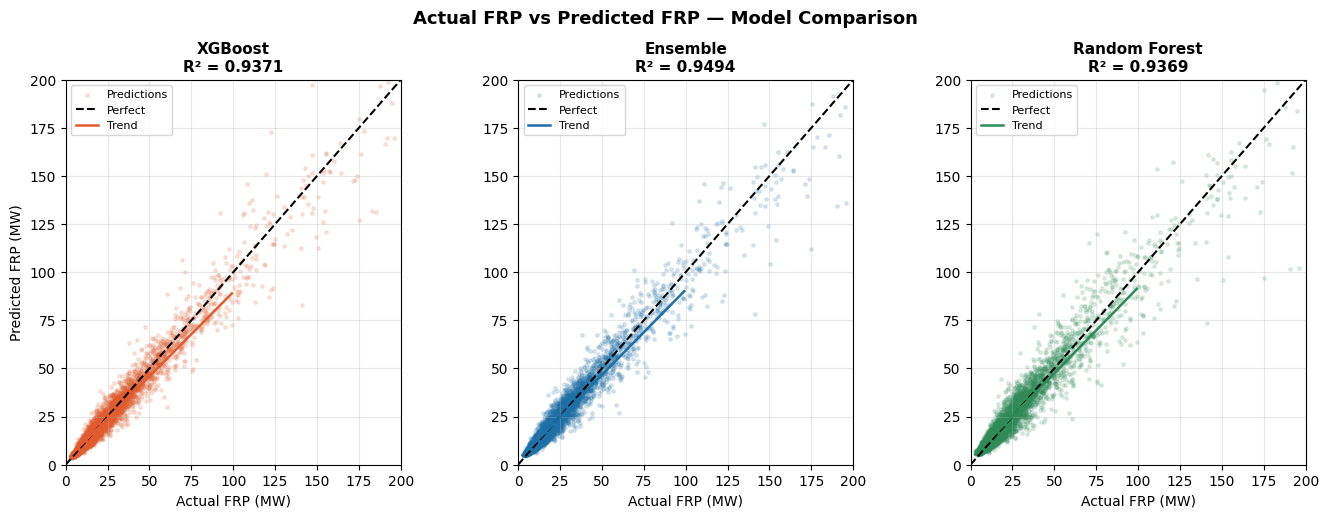

Saved: actual_vs_predicted.png


In [37]:
# ============================================================
# GRAPH 1 — Actual FRP vs Predicted FRP (Overall Relationship)
# ============================================================
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
from sklearn.metrics import r2_score

fig = plt.figure(figsize=(16, 5))
gs  = gridspec.GridSpec(1, 3, figure=fig, wspace=0.35)

models = {
    "XGBoost":  xgb_pred,
    "Ensemble": ensemble_pred,
    "Random Forest": rf_pred
}
colors = ["#e05c2e", "#1d6fa5", "#2e8b57"]

for idx, (name, pred) in enumerate(models.items()):
    ax  = fig.add_subplot(gs[idx])
    r2  = r2_score(y_test, pred)

    # Scatter
    ax.scatter(y_test, pred, alpha=0.15, s=6, color=colors[idx], label="Predictions")

    # Perfect prediction line
    lims = [0, min(y_test.max(), pred.max(), 300)]
    ax.plot(lims, lims, 'k--', linewidth=1.5, label="Perfect")

    # Trend line
    z = np.polyfit(y_test, pred, 1)
    p = np.poly1d(z)
    x_line = np.linspace(y_test.min(), y_test.quantile(0.98), 100)
    ax.plot(x_line, p(x_line), color=colors[idx], linewidth=1.8, label="Trend")

    ax.set_xlim(0, 200)
    ax.set_ylim(0, 200)
    ax.set_title(f"{name}\nR² = {r2:.4f}", fontsize=11, fontweight='bold')
    ax.set_xlabel("Actual FRP (MW)", fontsize=10)
    ax.set_ylabel("Predicted FRP (MW)" if idx == 0 else "", fontsize=10)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

fig.suptitle("Actual FRP vs Predicted FRP — Model Comparison", fontsize=13, fontweight='bold', y=1.02)
plt.savefig("actual_vs_predicted.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: actual_vs_predicted.png")

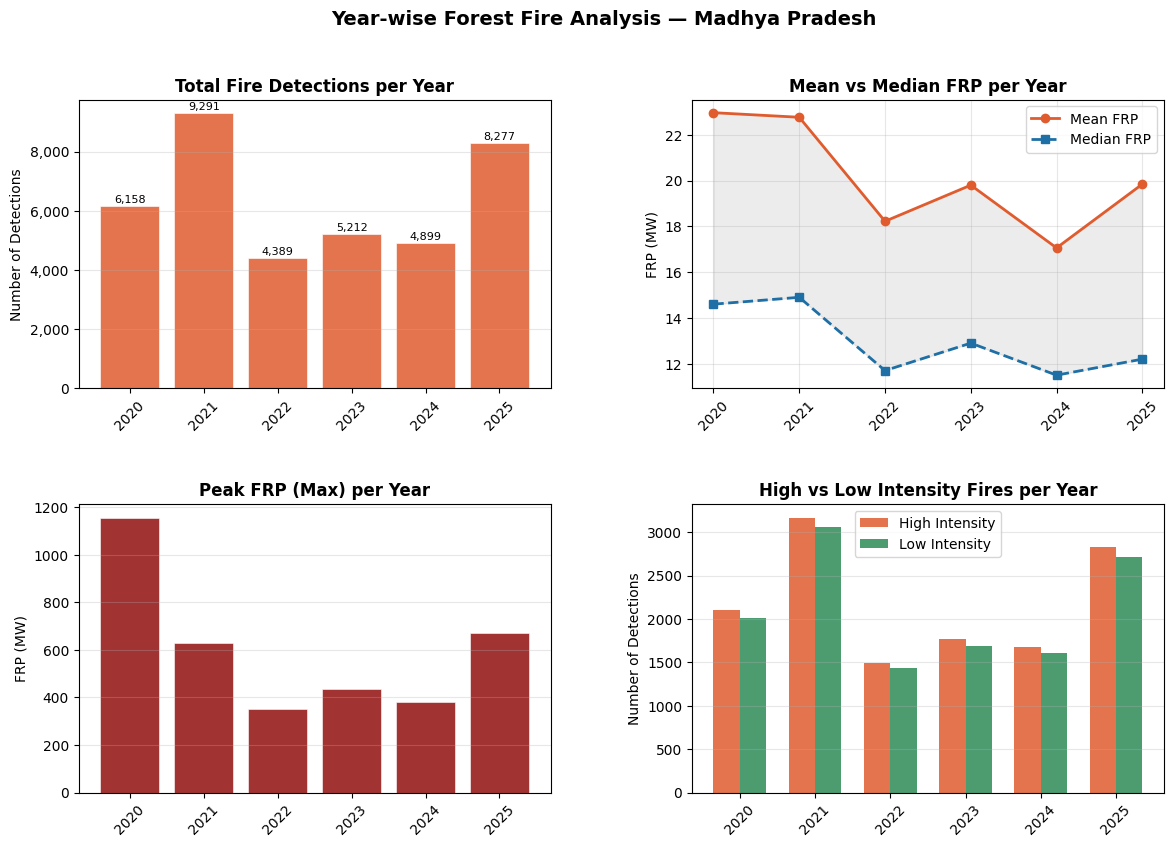

Saved: yearwise_fire_analysis.png


In [38]:
# ============================================================
# GRAPH 2 — Year-wise Fire Occurrence Analysis
# ============================================================
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

df['year'] = df['acq_date'].dt.year

# ── Per-year stats ──────────────────────────────────────────
yearly = df.groupby('year').agg(
    fire_count  = ('frp', 'count'),
    mean_frp    = ('frp', 'mean'),
    median_frp  = ('frp', 'median'),
    max_frp     = ('frp', 'max'),
    high_fires  = ('frp', lambda x: (x >= x.quantile(0.66)).sum()),
    low_fires   = ('frp', lambda x: (x <  x.quantile(0.33)).sum()),
).reset_index()

years = yearly['year'].astype(str).tolist()
x     = np.arange(len(years))

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle("Year-wise Forest Fire Analysis — Madhya Pradesh", fontsize=14, fontweight='bold')
plt.subplots_adjust(hspace=0.4, wspace=0.3)

# ── Plot 1: Total fire count per year ──
ax = axes[0, 0]
bars = ax.bar(x, yearly['fire_count'], color='#e05c2e', alpha=0.85, edgecolor='white', linewidth=0.5)
ax.set_xticks(x); ax.set_xticklabels(years, rotation=45)
ax.set_title("Total Fire Detections per Year", fontweight='bold')
ax.set_ylabel("Number of Detections")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{int(v):,}"))
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f"{int(bar.get_height()):,}", ha='center', va='bottom', fontsize=8)
ax.grid(axis='y', alpha=0.3)

# ── Plot 2: Mean & Median FRP per year ──
ax = axes[0, 1]
ax.plot(x, yearly['mean_frp'],   marker='o', color='#e05c2e', linewidth=2, label='Mean FRP')
ax.plot(x, yearly['median_frp'], marker='s', color='#1d6fa5', linewidth=2, linestyle='--', label='Median FRP')
ax.fill_between(x, yearly['median_frp'], yearly['mean_frp'], alpha=0.15, color='gray')
ax.set_xticks(x); ax.set_xticklabels(years, rotation=45)
ax.set_title("Mean vs Median FRP per Year", fontweight='bold')
ax.set_ylabel("FRP (MW)")
ax.legend(); ax.grid(alpha=0.3)

# ── Plot 3: Max FRP per year ──
ax = axes[1, 0]
ax.bar(x, yearly['max_frp'], color='#8b0000', alpha=0.8, edgecolor='white', linewidth=0.5)
ax.set_xticks(x); ax.set_xticklabels(years, rotation=45)
ax.set_title("Peak FRP (Max) per Year", fontweight='bold')
ax.set_ylabel("FRP (MW)")
ax.grid(axis='y', alpha=0.3)

# ── Plot 4: High vs Low fire count ──
ax = axes[1, 1]
w = 0.35
ax.bar(x - w/2, yearly['high_fires'], width=w, label='High Intensity', color='#e05c2e', alpha=0.85)
ax.bar(x + w/2, yearly['low_fires'],  width=w, label='Low Intensity',  color='#2e8b57', alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(years, rotation=45)
ax.set_title("High vs Low Intensity Fires per Year", fontweight='bold')
ax.set_ylabel("Number of Detections")
ax.legend(); ax.grid(axis='y', alpha=0.3)

plt.savefig("yearwise_fire_analysis.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: yearwise_fire_analysis.png")

Points in MP region: 38,226


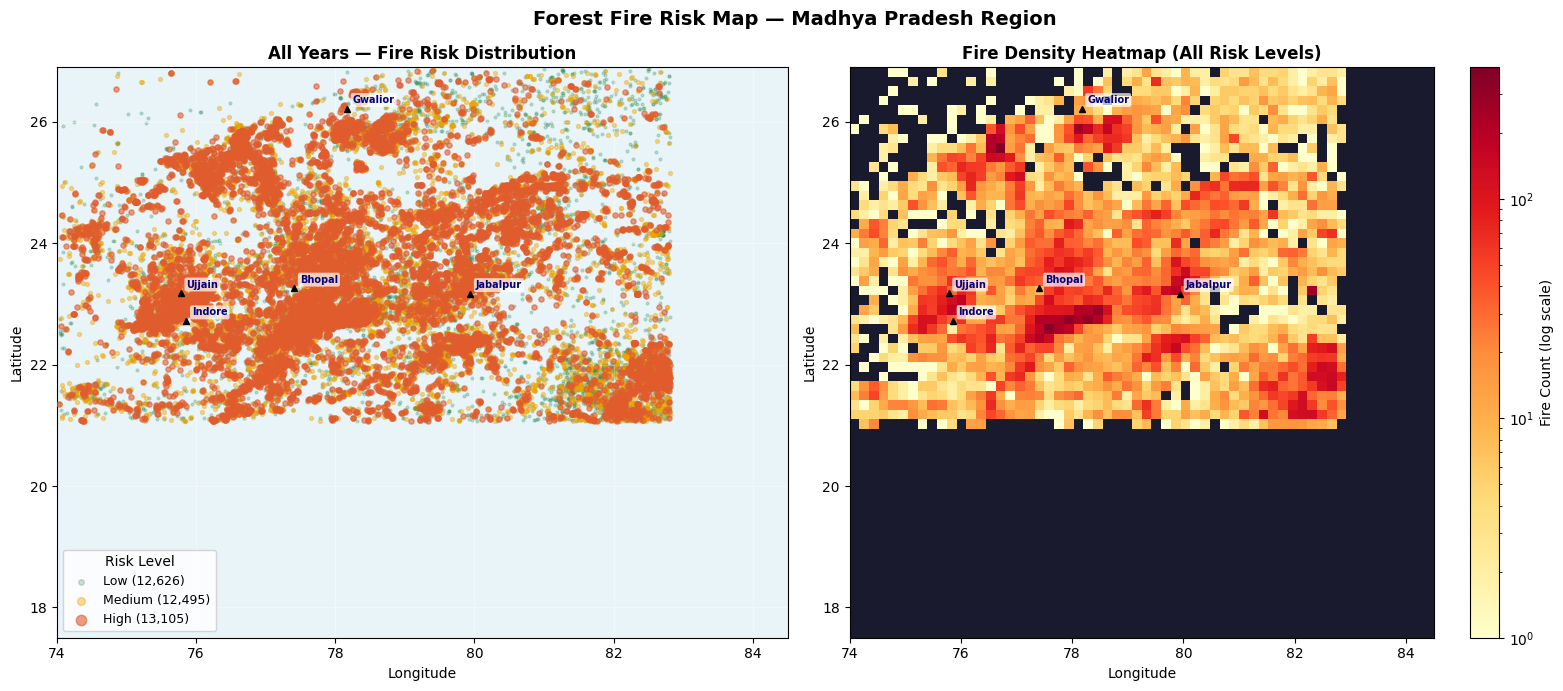

Saved: mp_fire_map.png


In [39]:
# ============================================================
# GRAPH 3 — Madhya Pradesh Fire Map (Low / Medium / High)
# ============================================================
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D

# ── Classify each point ─────────────────────────────────────
df['risk_level'] = df['frp'].apply(categorize)   # uses q1, q2 already defined

# ── Colour map ──────────────────────────────────────────────
color_map = {'Low': '#2e8b57', 'Medium': '#f0a500', 'High': '#e05c2e'}
size_map  = {'Low': 4,         'Medium': 8,          'High': 14}
alpha_map = {'Low': 0.25,      'Medium': 0.4,        'High': 0.6}
zorder_map= {'Low': 1,         'Medium': 2,          'High': 3}

# ── Madhya Pradesh rough bounding box ───────────────────────
LAT_MIN, LAT_MAX = 17.5, 26.9
LON_MIN, LON_MAX = 74.0, 84.5

mp_df = df[
    (df['latitude']  >= LAT_MIN) & (df['latitude']  <= LAT_MAX) &
    (df['longitude'] >= LON_MIN) & (df['longitude'] <= LON_MAX)
].copy()

print(f"Points in MP region: {len(mp_df):,}")

# ── Plot ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle("Forest Fire Risk Map — Madhya Pradesh Region",
             fontsize=14, fontweight='bold')

# Left: all years combined
ax = axes[0]
for level in ['Low', 'Medium', 'High']:
    sub = mp_df[mp_df['risk_level'] == level]
    ax.scatter(
        sub['longitude'], sub['latitude'],
        c=color_map[level], s=size_map[level],
        alpha=alpha_map[level], zorder=zorder_map[level],
        label=f"{level} ({len(sub):,})"
    )

ax.set_xlim(LON_MIN, LON_MAX)
ax.set_ylim(LAT_MIN, LAT_MAX)
ax.set_title("All Years — Fire Risk Distribution", fontweight='bold')
ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
ax.legend(title="Risk Level", markerscale=2, fontsize=9)
ax.set_facecolor('#e8f4f8')
ax.grid(True, alpha=0.4, color='white', linewidth=0.8)

# Right: density heatmap
ax2 = axes[1]
h = ax2.hist2d(
    mp_df['longitude'], mp_df['latitude'],
    bins=60,
    range=[[LON_MIN, LON_MAX], [LAT_MIN, LAT_MAX]],
    cmap='YlOrRd',
    norm=mcolors.LogNorm()
)
plt.colorbar(h[3], ax=ax2, label='Fire Count (log scale)')
ax2.set_xlim(LON_MIN, LON_MAX)
ax2.set_ylim(LAT_MIN, LAT_MAX)
ax2.set_title("Fire Density Heatmap (All Risk Levels)", fontweight='bold')
ax2.set_xlabel("Longitude"); ax2.set_ylabel("Latitude")
ax2.set_facecolor('#1a1a2e')

# Annotate major MP cities for reference
cities = {
    'Bhopal':    (77.41, 23.26),
    'Indore':    (75.86, 22.72),
    'Jabalpur':  (79.94, 23.17),
    'Gwalior':   (78.17, 26.22),
    'Ujjain':    (75.78, 23.18),
}
for name, (lon, lat) in cities.items():
    for ax in axes:
        ax.annotate(name, (lon, lat),
                    fontsize=7, fontweight='bold', color='navy',
                    xytext=(4, 4), textcoords='offset points',
                    bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.7, edgecolor='none'))
        ax.plot(lon, lat, 'k^', markersize=5, zorder=10)

plt.tight_layout()
plt.savefig("mp_fire_map.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: mp_fire_map.png")

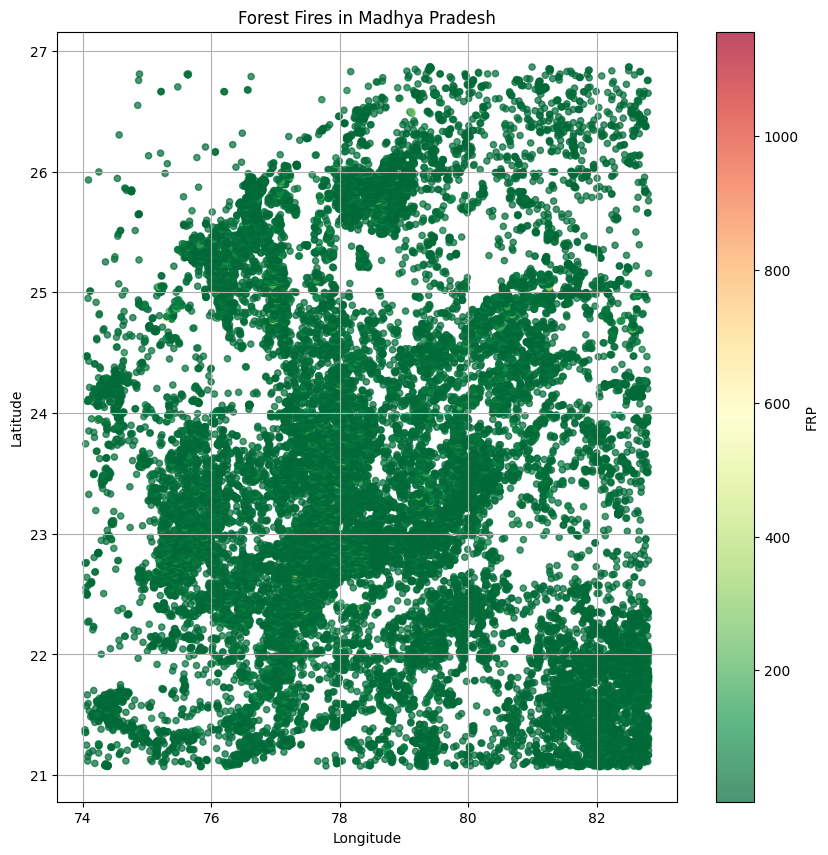

In [40]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,10))

scatter = plt.scatter(
    df["longitude"],
    df["latitude"],
    c=df["frp"],
    cmap="RdYlGn_r",
    s=20,
    alpha=0.7
)

plt.colorbar(scatter, label="FRP")

plt.title("Forest Fires in Madhya Pradesh")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.grid(True)

plt.show()